## 1. Análisis exploratorio de datos
Proyecto: Predicción de Temperatura y Alertas de Calor — David, Chiriquí, Panamá (1990–2026)

En este notebook analizamos el comportamiento histórico del clima de David
para entender los patrones que el modelo de IA deberá aprender.

Secciones:
1. Configuración y carga
2. Resumen estadístico general
3. Distribución de temperaturas
4. Evolución anual de temperatura
5. Patrones mensuales y estacionales
6. Análisis de lluvia
7. Análisis de humedad
8. Análisis de viento y presión
9. Tendencia de calentamiento (1990–2026)
10. Índice de Calor preliminar
11. Correlaciones entre variables
12. Días más extremos

In [6]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.config import *

# Estilo de graficas
plt.rcParams["figure.dpi"]      = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Entorno configurado correctamente.")

Entorno configurado correctamente.


## 2. Carga de dataset limpio

In [7]:
df = pd.read_csv(DATA_PROCESSED / "dataset_limpio.csv")
df["Fecha"] = pd.to_datetime(df["Fecha"])
df = df.sort_values("Fecha").reset_index(drop=True)

# Variables de tiempo utiles
df["Año"]   = df["Fecha"].dt.year
df["Mes"]   = df["Fecha"].dt.month
df["Dia"]   = df["Fecha"].dt.day

print("Dataset cargado correctamente.")
print(f"Filas    : {len(df):,} días")
print(f"Columnas : {df.columns.tolist()}")
print(f"Rango    : {df['Fecha'].min().date()} → {df['Fecha'].max().date()}")
print(f"Nulos    : {df.isnull().sum().sum()}")

Dataset cargado correctamente.
Filas    : 13,291 días
Columnas : ['Fecha', 'Temp_Max', 'Temp_Min', 'Temp_Prom', 'Humedad_Max', 'Humedad_Min', 'Humedad_Prom', 'Lluvia', 'Presion', 'Viento_Max', 'Año', 'Mes', 'Dia']
Rango    : 1990-01-01 → 2026-05-22
Nulos    : 0


## 3. Resumen estadístico general

In [8]:
resumen = df[[
    "Temp_Max","Temp_Min","Temp_Prom",
    "Humedad_Prom","Lluvia","Presion","Viento_Max"
]].describe().round(2)

print("Estadísticas descriptivas del dataset completo (1990–2026):")
resumen

Estadísticas descriptivas del dataset completo (1990–2026):


,Temp_Max,Temp_Min,Temp_Prom,Humedad_Prom,Lluvia,Presion,Viento_Max
count,13291.00,13291.00,13291.00,13291.00,13291.00,13291.00,13291.00
mean,29.74,22.22,25.32,81.90,10.73,1005.59,8.78
std,2.44,1.02,1.41,12.82,14.14,1.25,2.67
min,22.50,18.40,21.66,37.38,0.00,999.30,3.40
25%,28.00,21.50,24.30,74.15,1.40,1004.81,7.00
50%,29.30,22.20,25.03,87.50,7.20,1005.65,8.30
75%,31.50,22.80,26.28,91.33,15.00,1006.45,10.00
max,38.10,26.20,30.22,99.62,200.00,1010.05,32.70


In [9]:
# Resumen ejecutivo en texto
print("=" * 55)
print("  RESUMEN CLIMÁTICO — DAVID, CHIRIQUÍ 1990–2026")
print("=" * 55)
print(f"  Temperatura máxima histórica  : {df['Temp_Max'].max():.1f} °C")
print(f"  Temperatura mínima histórica  : {df['Temp_Min'].min():.1f} °C")
print(f"  Temperatura promedio general  : {df['Temp_Prom'].mean():.1f} °C")
print(f"  Día más lluvioso              : {df['Lluvia'].max():.1f} mm")
print(f"  Humedad promedio general      : {df['Humedad_Prom'].mean():.1f} %")
print(f"  Viento máximo registrado      : {df['Viento_Max'].max():.1f} km/h")
print(f"  Total de días analizados      : {len(df):,}")
print("=" * 55)

  RESUMEN CLIMÁTICO — DAVID, CHIRIQUÍ 1990–2026
  Temperatura máxima histórica  : 38.1 °C
  Temperatura mínima histórica  : 18.4 °C
  Temperatura promedio general  : 25.3 °C
  Día más lluvioso              : 200.0 mm
  Humedad promedio general      : 81.9 %
  Viento máximo registrado      : 32.7 km/h
  Total de días analizados      : 13,291


## 4. Distribución de temperaturas

Visualizamos cómo se distribuyen las temperaturas máxima, mínima
y promedio a lo largo de los 36 años.

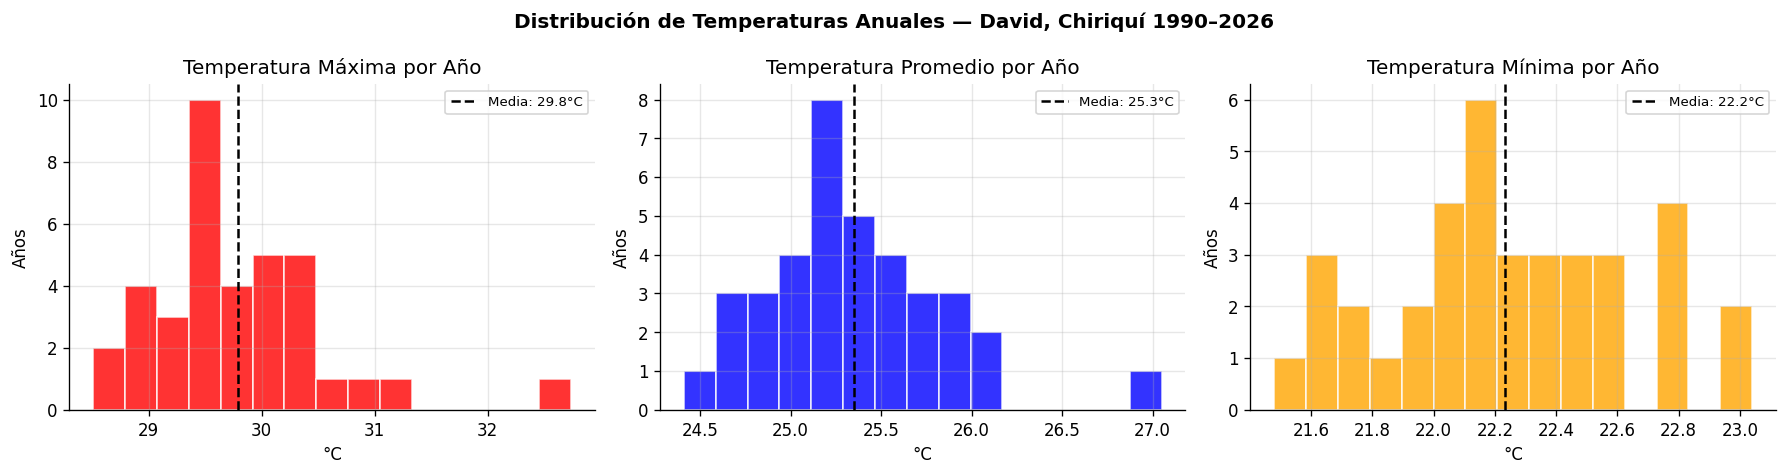

Gráfica guardada en reports/


In [12]:
# Calcular promedios anuales primero
anual = df.groupby("Año").agg(
    Temp_Max  = ("Temp_Max",  "mean"),
    Temp_Prom = ("Temp_Prom", "mean"),
    Temp_Min  = ("Temp_Min",  "mean"),
).round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    ("Temp_Max",  "Temperatura Máxima por Año",   "red"),
    ("Temp_Prom", "Temperatura Promedio por Año",  "blue"),
    ("Temp_Min",  "Temperatura Mínima por Año",    "orange"),
]

for ax, (col, titulo, color) in zip(axes, configs):
    ax.hist(anual[col], bins=15, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(anual[col].mean(), color="black", linestyle="--",
               linewidth=1.5, label=f"Media: {anual[col].mean():.1f}°C")
    ax.set_title(titulo)
    ax.set_xlabel("°C")
    ax.set_ylabel("Años")       # ← cambió de Días a Años
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Distribución de Temperaturas Anuales — David, Chiriquí 1990–2026",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "distribucion_temperaturas_anuales.png", dpi=150)
plt.show()
print("Gráfica guardada en reports/")

## 5. Evolución anual de temperatura

Analizamos cómo ha cambiado la temperatura año a año desde 1990.

In [13]:
anual = df.groupby("Año").agg(
    Temp_Max_Prom  = ("Temp_Max",  "mean"),
    Temp_Prom_Prom = ("Temp_Prom", "mean"),
    Temp_Min_Prom  = ("Temp_Min",  "mean"),
).round(2)

print("Temperatura promedio por año:")
print(anual.to_string())

Temperatura promedio por año:
      Temp_Max_Prom  Temp_Prom_Prom  Temp_Min_Prom
Año                                               
1990          29.61           25.32          22.19
1991          29.59           25.27          22.04
1992          29.90           25.42          22.14
1993          29.39           25.05          21.86
1994          29.62           25.26          21.97
1995          29.00           24.88          21.90
1996          28.93           24.76          21.75
1997          30.43           25.80          22.55
1998          30.08           25.81          22.76
1999          28.51           24.41          21.48
2000          29.13           24.80          21.64
2001          29.47           25.15          22.04
2002          30.09           25.61          22.38
2003          29.54           25.26          22.26
2004          29.52           25.29          22.23
2005          29.14           25.05          22.18
2006          29.49           25.19          22.14
2

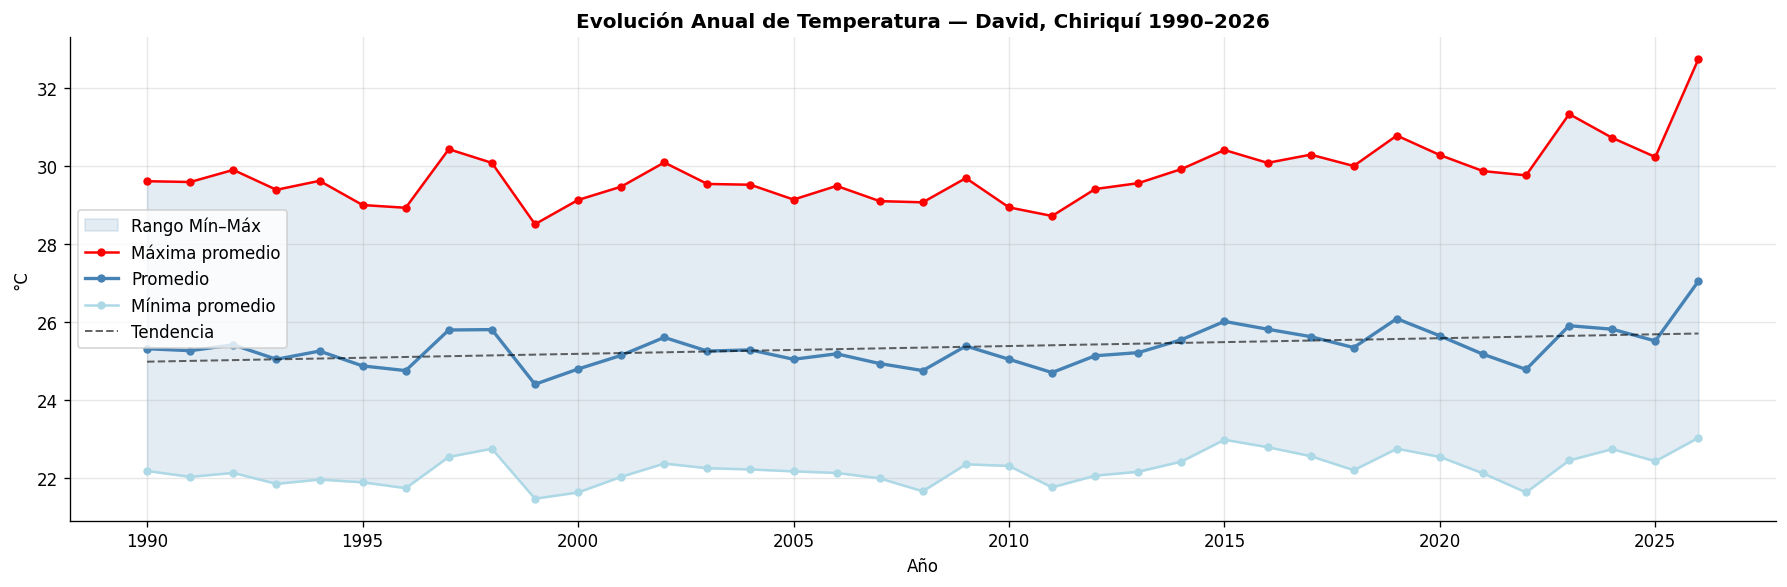

Tendencia de calentamiento 1990–2026: +0.72°C en 36 años


In [14]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.fill_between(anual.index, anual["Temp_Min_Prom"], anual["Temp_Max_Prom"],
                alpha=0.15, color="steelblue", label="Rango Mín–Máx")
ax.plot(anual.index, anual["Temp_Max_Prom"],
        color="red", linewidth=1.5, marker="o", markersize=4, label="Máxima promedio")
ax.plot(anual.index, anual["Temp_Prom_Prom"],
        color="steelblue", linewidth=2, marker="o", markersize=4, label="Promedio")
ax.plot(anual.index, anual["Temp_Min_Prom"],
        color="lightblue", linewidth=1.5, marker="o", markersize=4, label="Mínima promedio")

# Línea de tendencia
z = np.polyfit(anual.index, anual["Temp_Prom_Prom"], 1)
p = np.poly1d(z)
ax.plot(anual.index, p(anual.index), "k--", linewidth=1.2, alpha=0.6, label="Tendencia")

ax.set_title("Evolución Anual de Temperatura — David, Chiriquí 1990–2026",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("°C")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "evolucion_anual_temperatura.png", dpi=150)
plt.show()

# Tendencia calculada
cambio = p(anual.index[-1]) - p(anual.index[0])
print(f"Tendencia de calentamiento 1990–2026: +{cambio:.2f}°C en 36 años")

## 6. Patrones mensuales y estacionales

David tiene dos estaciones: **verano** (dic–abr) y **lluvioso** (may–nov).
Analizamos cómo varía el clima entre ellas.

In [15]:
meses_nombres = {
    1:"Ene", 2:"Feb", 3:"Mar", 4:"Abr",
    5:"May", 6:"Jun", 7:"Jul", 8:"Ago",
    9:"Sep", 10:"Oct", 11:"Nov", 12:"Dic"
}

mensual = df.groupby("Mes").agg(
    Temp_Max_Prom  = ("Temp_Max",    "mean"),
    Temp_Prom_Prom = ("Temp_Prom",   "mean"),
    Temp_Min_Prom  = ("Temp_Min",    "mean"),
    Lluvia_Prom    = ("Lluvia",      "mean"),
    Humedad_Prom   = ("Humedad_Prom","mean"),
).round(2)

mensual.index = [meses_nombres[m] for m in mensual.index]
print("Promedios mensuales:")
print(mensual.to_string())

Promedios mensuales:
     Temp_Max_Prom  Temp_Prom_Prom  Temp_Min_Prom  Lluvia_Prom  Humedad_Prom
Ene          31.09           25.80          21.79         1.70         70.66
Feb          32.67           26.85          22.48         1.28         63.39
Mar          33.37           27.40          22.95         1.70         63.23
Abr          32.05           26.79          23.05         6.08         73.32
May          29.39           25.37          22.72        14.90         87.26
Jun          28.47           24.83          22.37        15.28         90.42
Jul          28.52           24.76          22.16        13.90         89.53
Ago          28.34           24.62          22.11        14.98         90.25
Sep          28.21           24.40          21.95        15.63         91.10
Oct          27.69           24.07          21.78        19.55         91.68
Nov          27.82           24.12          21.65        17.87         90.14
Dic          29.21           24.81          21.61      

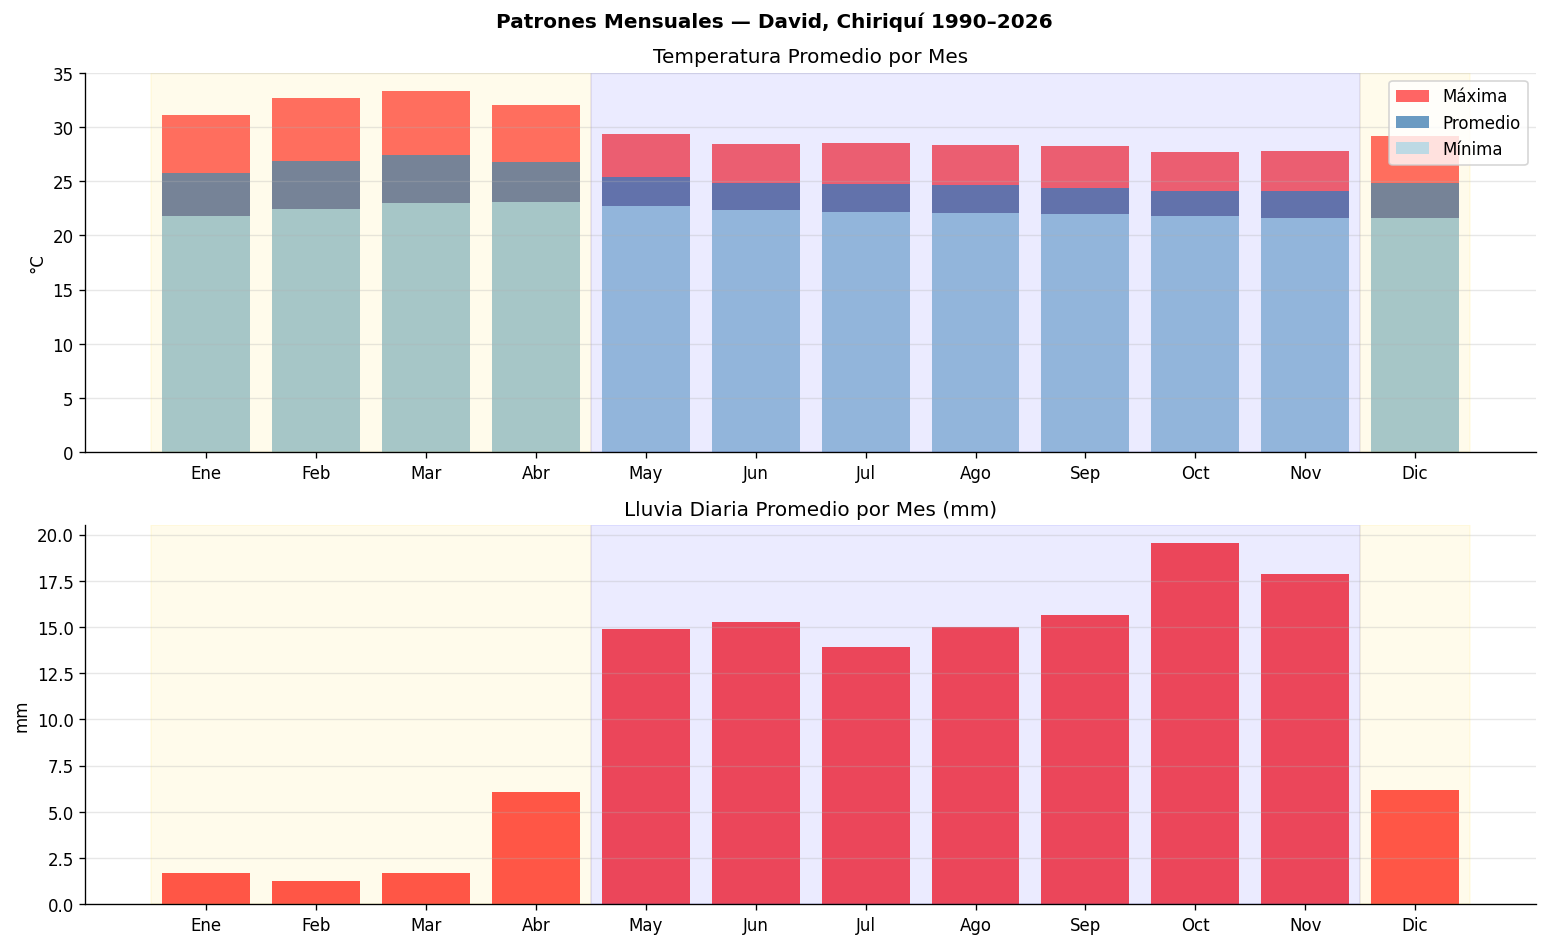

Gráfica guardada en reports/


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

meses_labels = list(meses_nombres.values())
colores_mes = ["gold"]*4 + ["steelblue"]*7 + ["gold"]*1  # verano=dorado, lluvia=azul

# Temperatura por mes
axes[0].bar(meses_labels, mensual["Temp_Max_Prom"],
            color="red", alpha=0.6, label="Máxima")
axes[0].bar(meses_labels, mensual["Temp_Prom_Prom"],
            color="steelblue", alpha=0.8, label="Promedio")
axes[0].bar(meses_labels, mensual["Temp_Min_Prom"],
            color="lightblue", alpha=0.8, label="Mínima")
axes[0].set_title("Temperatura Promedio por Mes")
axes[0].set_ylabel("°C")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
axes[0].axvspan(-0.5, 3.5, alpha=0.08, color="gold", label="Verano")
axes[0].axvspan(3.5, 10.5, alpha=0.08, color="blue")
axes[0].axvspan(10.5, 11.5, alpha=0.08, color="gold")

# Lluvia por mes
axes[1].bar(meses_labels, mensual["Lluvia_Prom"],
            color="red", alpha=0.7)
axes[1].set_title("Lluvia Diaria Promedio por Mes (mm)")
axes[1].set_ylabel("mm")
axes[1].grid(axis="y", alpha=0.3)
axes[1].axvspan(-0.5, 3.5, alpha=0.08, color="gold")
axes[1].axvspan(3.5, 10.5, alpha=0.08, color="blue")
axes[1].axvspan(10.5, 11.5, alpha=0.08, color="gold")

plt.suptitle("Patrones Mensuales — David, Chiriquí 1990–2026",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "patrones_mensuales.png", dpi=150)
plt.show()
print("Gráfica guardada en reports/")

In [17]:
# Comparacion verano vs lluvioso
df["Estacion"] = df["Mes"].apply(
    lambda m: "Verano (Dic–Abr)" if m in [12,1,2,3,4] else "Lluvioso (May–Nov)"
)

comp = df.groupby("Estacion").agg(
    Temp_Max_Prom  = ("Temp_Max",    "mean"),
    Temp_Prom_Prom = ("Temp_Prom",   "mean"),
    Lluvia_Prom    = ("Lluvia",      "mean"),
    Humedad_Prom   = ("Humedad_Prom","mean"),
).round(2)

print("Comparación por estación:")
print(comp.to_string())

Comparación por estación:
                    Temp_Max_Prom  Temp_Prom_Prom  Lluvia_Prom  Humedad_Prom
Estacion                                                                    
Lluvioso (May–Nov)          28.35           24.60        16.01         90.04
Verano (Dic–Abr)            31.67           26.32         3.39         70.59


## 7. Análisis de lluvia

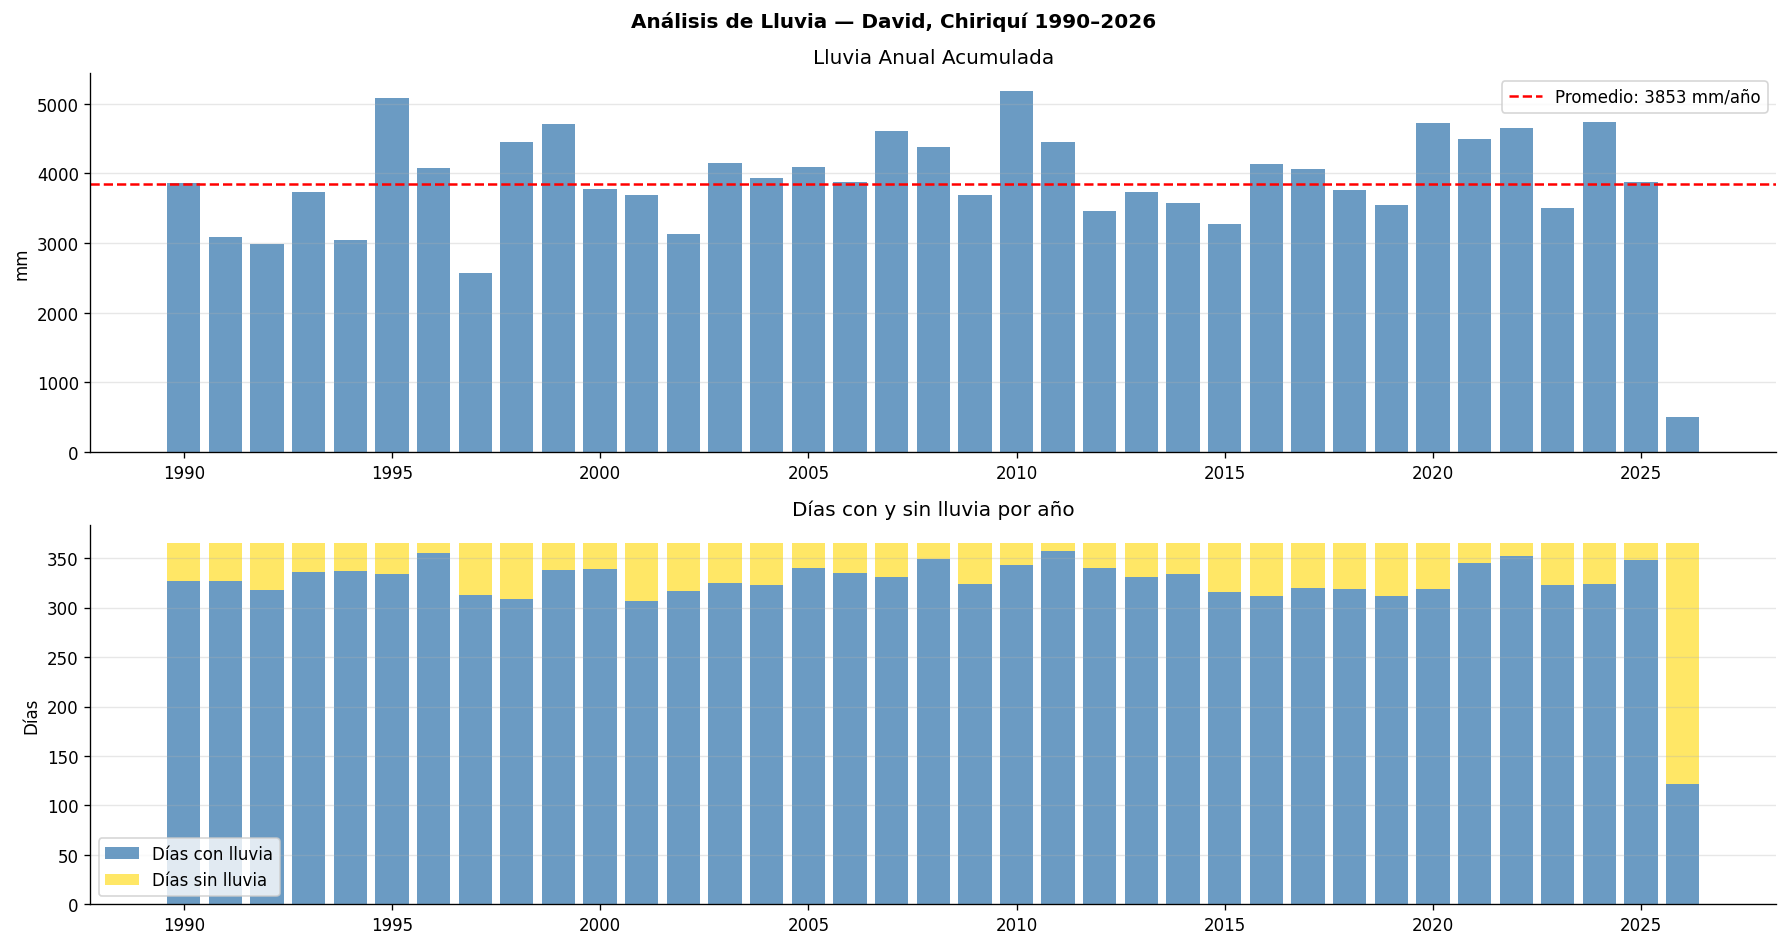

Gráfica guardada en reports/


In [18]:
lluvia_anual = df.groupby("Año")["Lluvia"].sum().round(1)

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Lluvia anual acumulada
axes[0].bar(lluvia_anual.index, lluvia_anual.values,
            color="steelblue", alpha=0.8)
axes[0].axhline(lluvia_anual.mean(), color="red", linestyle="--",
                linewidth=1.5, label=f"Promedio: {lluvia_anual.mean():.0f} mm/año")
axes[0].set_title("Lluvia Anual Acumulada")
axes[0].set_ylabel("mm")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Dias con lluvia vs sin lluvia por año
dias_lluvia = df.groupby("Año").apply(
    lambda x: (x["Lluvia"] > 0).sum()
).reset_index()
dias_lluvia.columns = ["Año", "Dias_con_lluvia"]
dias_lluvia["Dias_sin_lluvia"] = 365 - dias_lluvia["Dias_con_lluvia"]

axes[1].bar(dias_lluvia["Año"], dias_lluvia["Dias_con_lluvia"],
            color="steelblue", alpha=0.8, label="Días con lluvia")
axes[1].bar(dias_lluvia["Año"], dias_lluvia["Dias_sin_lluvia"],
            bottom=dias_lluvia["Dias_con_lluvia"],
            color="gold", alpha=0.6, label="Días sin lluvia")
axes[1].set_title("Días con y sin lluvia por año")
axes[1].set_ylabel("Días")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Análisis de Lluvia — David, Chiriquí 1990–2026",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "analisis_lluvia.png", dpi=150)
plt.show()
print("Gráfica guardada en reports/")

## 8. Análisis de humedad

La humedad real es uno de los datos más importantes para el índice de calor.
A diferencia del dataset anterior, aquí tenemos humedad medida, no estimada.

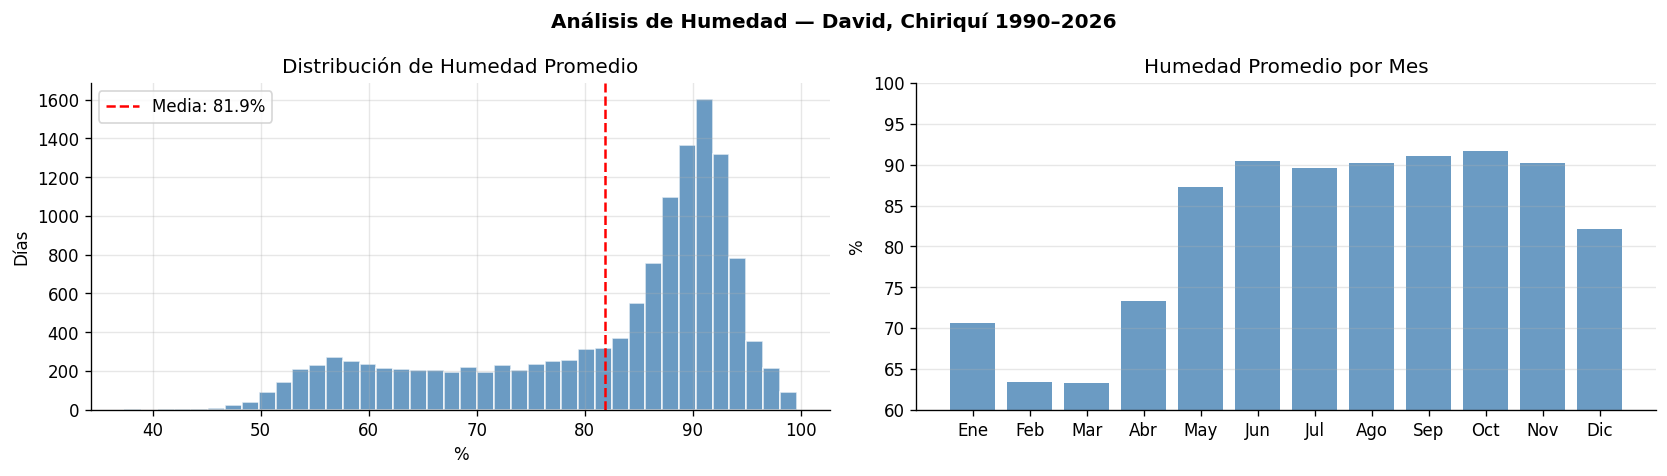

Gráfica guardada en reports/


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribucion de humedad
axes[0].hist(df["Humedad_Prom"], bins=40,
             color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axvline(df["Humedad_Prom"].mean(), color="red", linestyle="--",
                linewidth=1.5, label=f"Media: {df['Humedad_Prom'].mean():.1f}%")
axes[0].set_title("Distribución de Humedad Promedio")
axes[0].set_xlabel("%")
axes[0].set_ylabel("Días")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Humedad por mes
humedad_mensual = df.groupby("Mes")["Humedad_Prom"].mean()
axes[1].bar([meses_nombres[m] for m in humedad_mensual.index],
            humedad_mensual.values, color="steelblue", alpha=0.8)
axes[1].set_title("Humedad Promedio por Mes")
axes[1].set_ylabel("%")
axes[1].set_ylim(60, 100)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Análisis de Humedad — David, Chiriquí 1990–2026",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "analisis_humedad.png", dpi=150)
plt.show()
print("Gráfica guardada en reports/")

## 9. Análisis de viento y presión

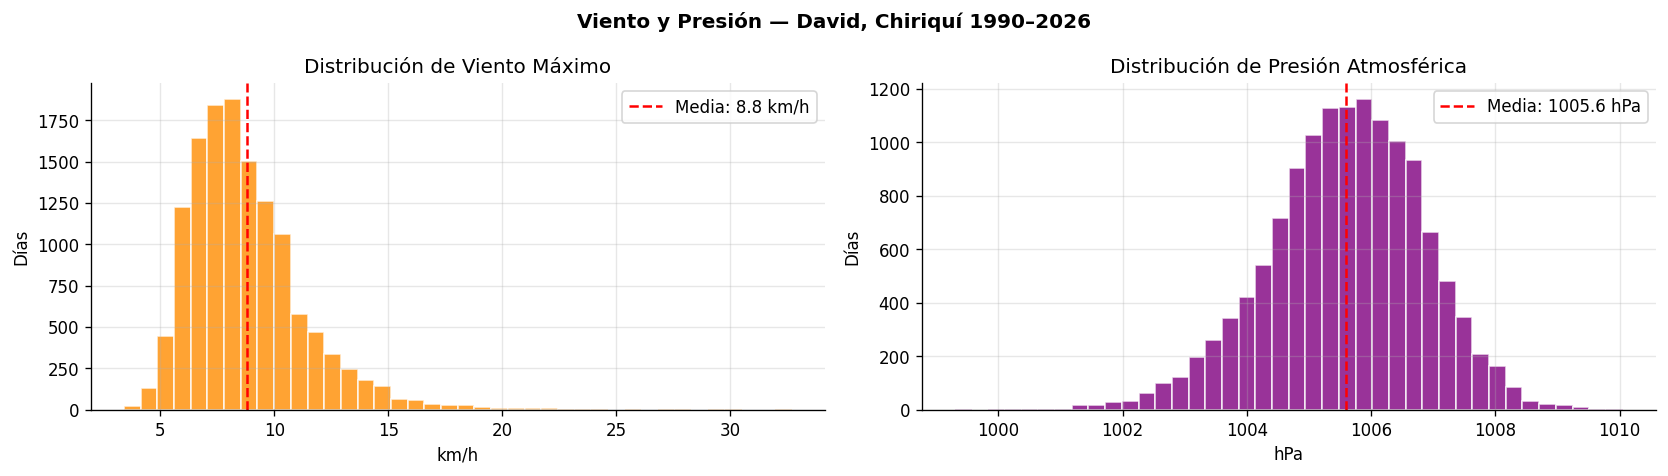

Gráfica guardada en reports/


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Viento
axes[0].hist(df["Viento_Max"], bins=40,
             color="darkorange", alpha=0.8, edgecolor="white")
axes[0].axvline(df["Viento_Max"].mean(), color="red", linestyle="--",
                linewidth=1.5, label=f"Media: {df['Viento_Max'].mean():.1f} km/h")
axes[0].set_title("Distribución de Viento Máximo")
axes[0].set_xlabel("km/h")
axes[0].set_ylabel("Días")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Presion
axes[1].hist(df["Presion"], bins=40,
             color="purple", alpha=0.8, edgecolor="white")
axes[1].axvline(df["Presion"].mean(), color="red", linestyle="--",
                linewidth=1.5, label=f"Media: {df['Presion'].mean():.1f} hPa")
axes[1].set_title("Distribución de Presión Atmosférica")
axes[1].set_xlabel("hPa")
axes[1].set_ylabel("Días")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Viento y Presión — David, Chiriquí 1990–2026",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "analisis_viento_presion.png", dpi=150)
plt.show()
print("Gráfica guardada en reports/")

## 10. Tendencia de calentamiento 1990–2026

Analizamos si David ha experimentado un calentamiento progresivo
a lo largo de los 36 años. Este análisis es valioso para el paper.

In [21]:
decadas = df.groupby((df["Año"] // 10) * 10).agg(
    Temp_Max_Prom  = ("Temp_Max",  "mean"),
    Temp_Prom_Prom = ("Temp_Prom", "mean"),
    Lluvia_Anual   = ("Lluvia",    "sum"),
    Dias_Calor     = ("Temp_Max",  lambda x: (x >= 35).sum()),
).round(2)

print("Resumen por década:")
print(decadas.to_string())
print()

# Diferencia entre primera y ultima decada
primera = decadas.iloc[0]
ultima  = decadas.iloc[-1]
print(f"Cambio en Temp Máx promedio : +{ultima['Temp_Max_Prom'] - primera['Temp_Max_Prom']:.2f}°C")
print(f"Cambio en Temp Prom         : +{ultima['Temp_Prom_Prom'] - primera['Temp_Prom_Prom']:.2f}°C")
print(f"Cambio en días calurosos    : +{ultima['Dias_Calor'] - primera['Dias_Calor']:.0f} días/década")

Resumen por década:
      Temp_Max_Prom  Temp_Prom_Prom  Lluvia_Anual  Dias_Calor
Año                                                          
1990          29.51           25.20       37596.7          31
2000          29.42           25.14       39316.6           2
2010          29.81           25.46       39181.2          82
2020          30.51           25.57       26484.6         119

Cambio en Temp Máx promedio : +1.00°C
Cambio en Temp Prom         : +0.37°C
Cambio en días calurosos    : +88 días/década


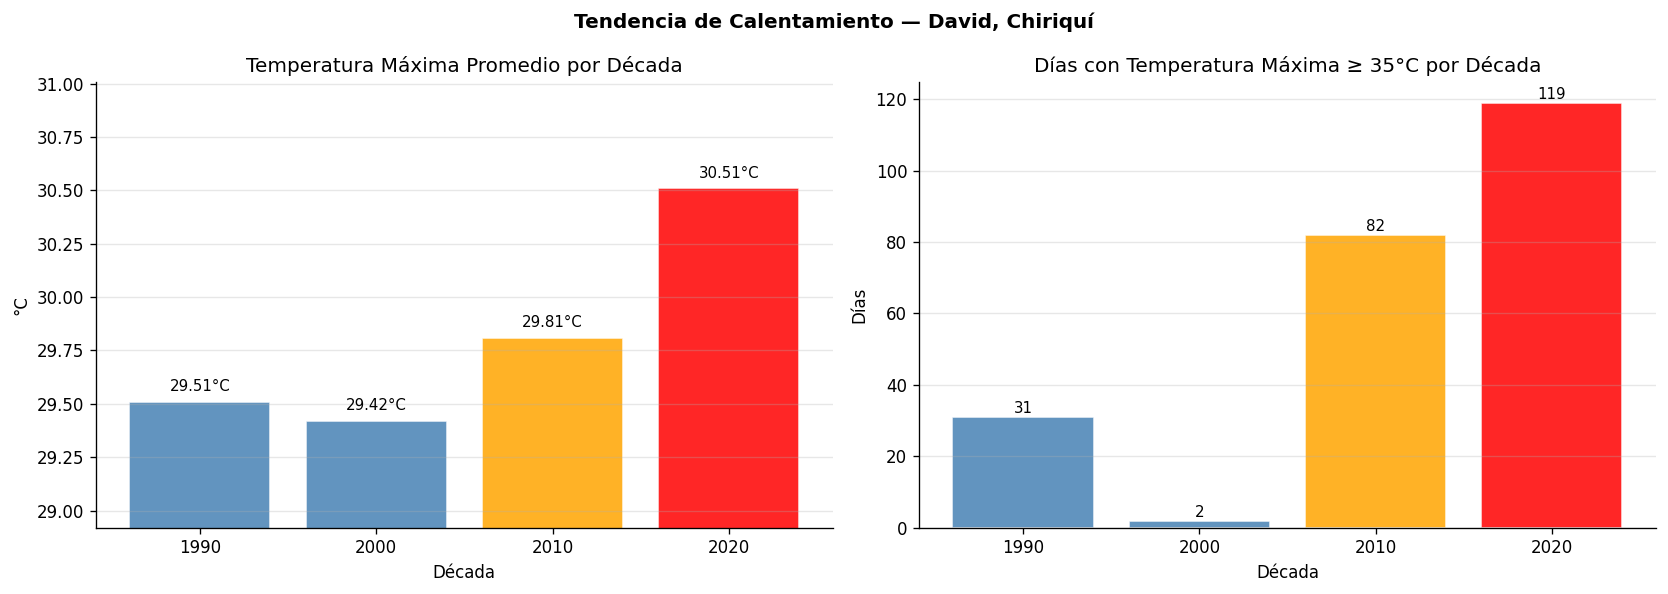

Gráfica guardada en reports/


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temperatura maxima promedio por decada
axes[0].bar(decadas.index.astype(str), decadas["Temp_Max_Prom"],
            color=["steelblue","steelblue","orange","red"],
            alpha=0.85, edgecolor="white")
axes[0].set_title("Temperatura Máxima Promedio por Década")
axes[0].set_xlabel("Década")
axes[0].set_ylabel("°C")
axes[0].set_ylim(decadas["Temp_Max_Prom"].min() - 0.5,
                 decadas["Temp_Max_Prom"].max() + 0.5)
axes[0].grid(axis="y", alpha=0.3)
for i, (idx, val) in enumerate(decadas["Temp_Max_Prom"].items()):
    axes[0].text(i, val + 0.05, f"{val:.2f}°C", ha="center", fontsize=9)

# Dias con temp maxima >= 35°C por decada
axes[1].bar(decadas.index.astype(str), decadas["Dias_Calor"],
            color=["steelblue","steelblue","orange","red"],
            alpha=0.85, edgecolor="white")
axes[1].set_title("Días con Temperatura Máxima ≥ 35°C por Década")
axes[1].set_xlabel("Década")
axes[1].set_ylabel("Días")
axes[1].grid(axis="y", alpha=0.3)
for i, (idx, val) in enumerate(decadas["Dias_Calor"].items()):
    axes[1].text(i, val + 1, f"{val:.0f}", ha="center", fontsize=9)

plt.suptitle("Tendencia de Calentamiento — David, Chiriquí",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "tendencia_calentamiento.png", dpi=150)
plt.show()
print("Gráfica guardada en reports/")

## 11. Índice de Calor preliminar

Calculamos el Índice de Calor con la fórmula de Rothfusz usando
la humedad real que nos provee Open-Meteo.
Esta es una ventaja importante sobre el dataset anterior.

In [23]:
T = df["Temp_Max"]
H = df["Humedad_Prom"]

df["Indice_Calor"] = (
    -8.78469475556
    + 1.61139411    * T
    + 2.33854883889 * H
    - 0.14611605    * T * H
    - 0.012308094   * T**2
    - 0.0164248277778 * H**2
    + 0.002211732   * T**2 * H
    + 0.00072546    * T    * H**2
    - 0.000003582   * T**2 * H**2
).round(1)

def nivel_alerta(i):
    if i >= 41:   return "PELIGRO EXTREMO"
    elif i >= 35: return "PELIGRO"
    elif i >= 32: return "PRECAUCION"
    else:         return "NORMAL"

df["Nivel_Alerta"] = df["Indice_Calor"].apply(nivel_alerta)

print("Índice de Calor calculado.")
print()
print("Estadísticas:")
print(df["Indice_Calor"].describe().round(2))
print()
print("Distribución de niveles de alerta:")
conteo = df["Nivel_Alerta"].value_counts()
for nivel, cant in conteo.items():
    pct = cant / len(df) * 100
    print(f"  {nivel:20s}: {cant:5,} días ({pct:.1f}%)")

Índice de Calor calculado.

Estadísticas:
count    13291.00
mean        36.87
std          5.13
min         19.40
25%         33.65
50%         36.60
75%         39.80
max         59.10
Name: Indice_Calor, dtype: float64

Distribución de niveles de alerta:
  PELIGRO             : 6,072 días (45.7%)
  PRECAUCION          : 2,748 días (20.7%)
  PELIGRO EXTREMO     : 2,499 días (18.8%)
  NORMAL              : 1,972 días (14.8%)


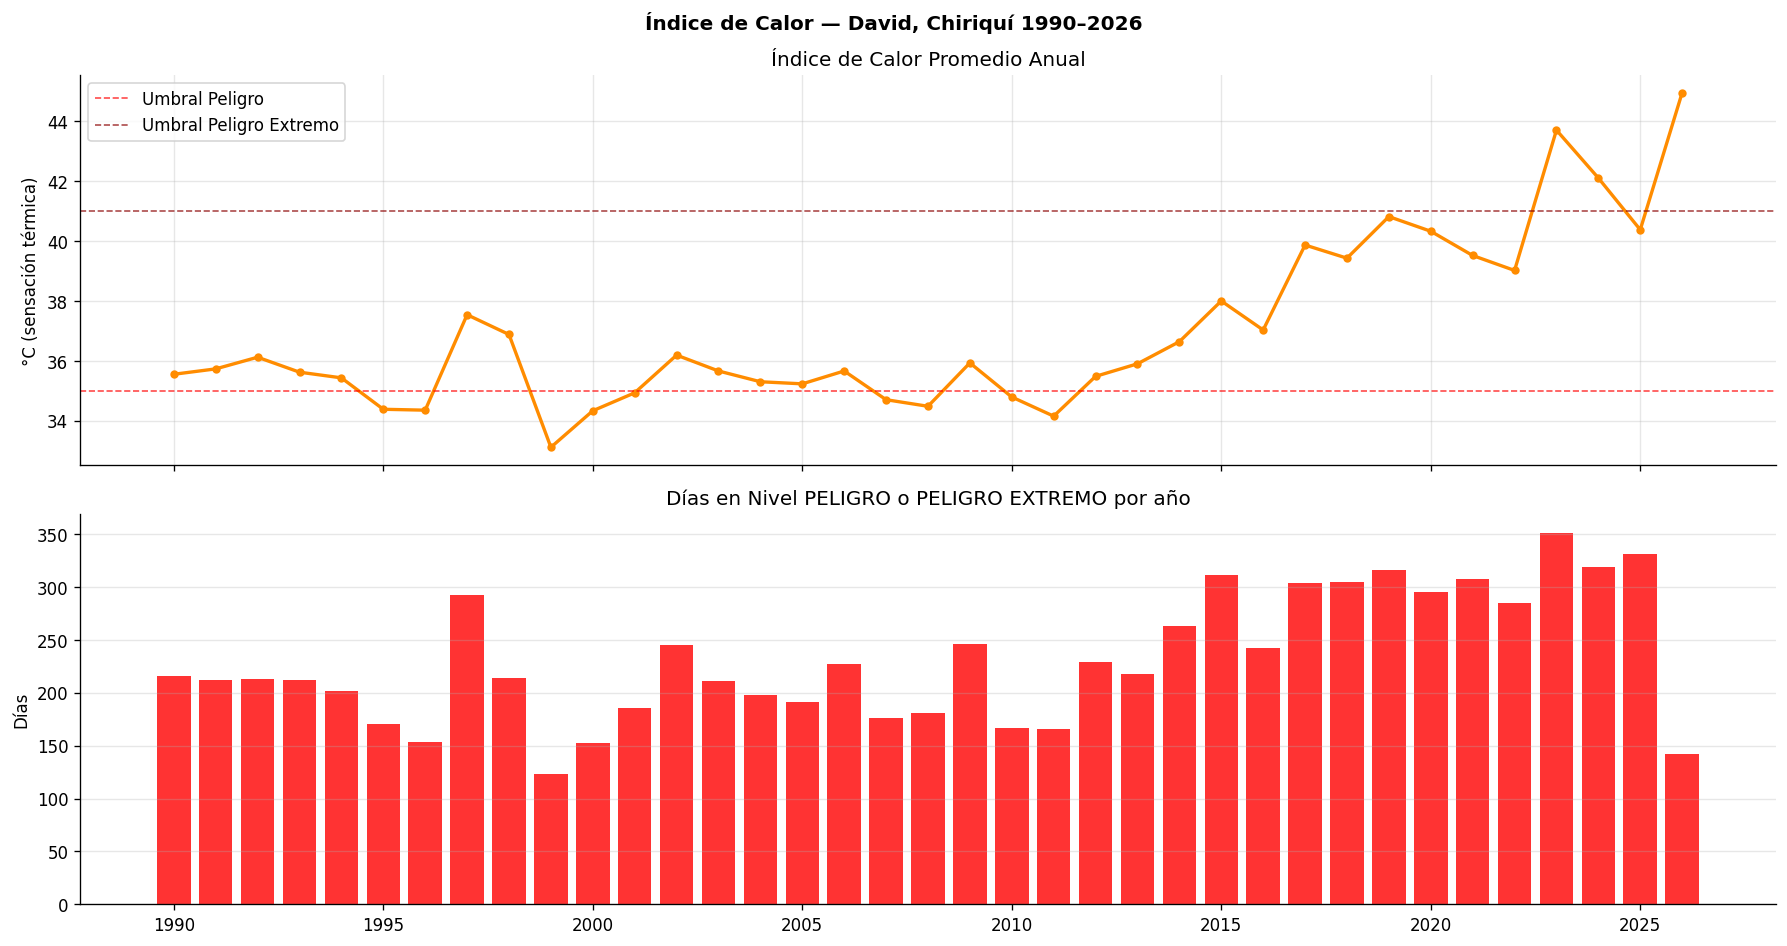

Gráfica guardada en reports/


In [24]:
# Evolucion del indice de calor por año
calor_anual = df.groupby("Año")["Indice_Calor"].mean().round(2)
dias_peligro = df[df["Nivel_Alerta"].isin(["PELIGRO","PELIGRO EXTREMO"])].groupby("Año").size()

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(calor_anual.index, calor_anual.values,
             color="darkorange", linewidth=2, marker="o", markersize=4)
axes[0].axhline(35, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Umbral Peligro")
axes[0].axhline(41, color="darkred", linestyle="--", linewidth=1, alpha=0.7, label="Umbral Peligro Extremo")
axes[0].set_title("Índice de Calor Promedio Anual")
axes[0].set_ylabel("°C (sensación térmica)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(dias_peligro.index, dias_peligro.values,
            color="red", alpha=0.8)
axes[1].set_title("Días en Nivel PELIGRO o PELIGRO EXTREMO por año")
axes[1].set_ylabel("Días")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Índice de Calor — David, Chiriquí 1990–2026",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "indice_calor_historico.png", dpi=150)
plt.show()
print("Gráfica guardada en reports/")

## 12. Correlaciones entre variables

Analizamos qué variables están más relacionadas entre sí.
Esto ayuda a entender qué features serán más útiles para el modelo.

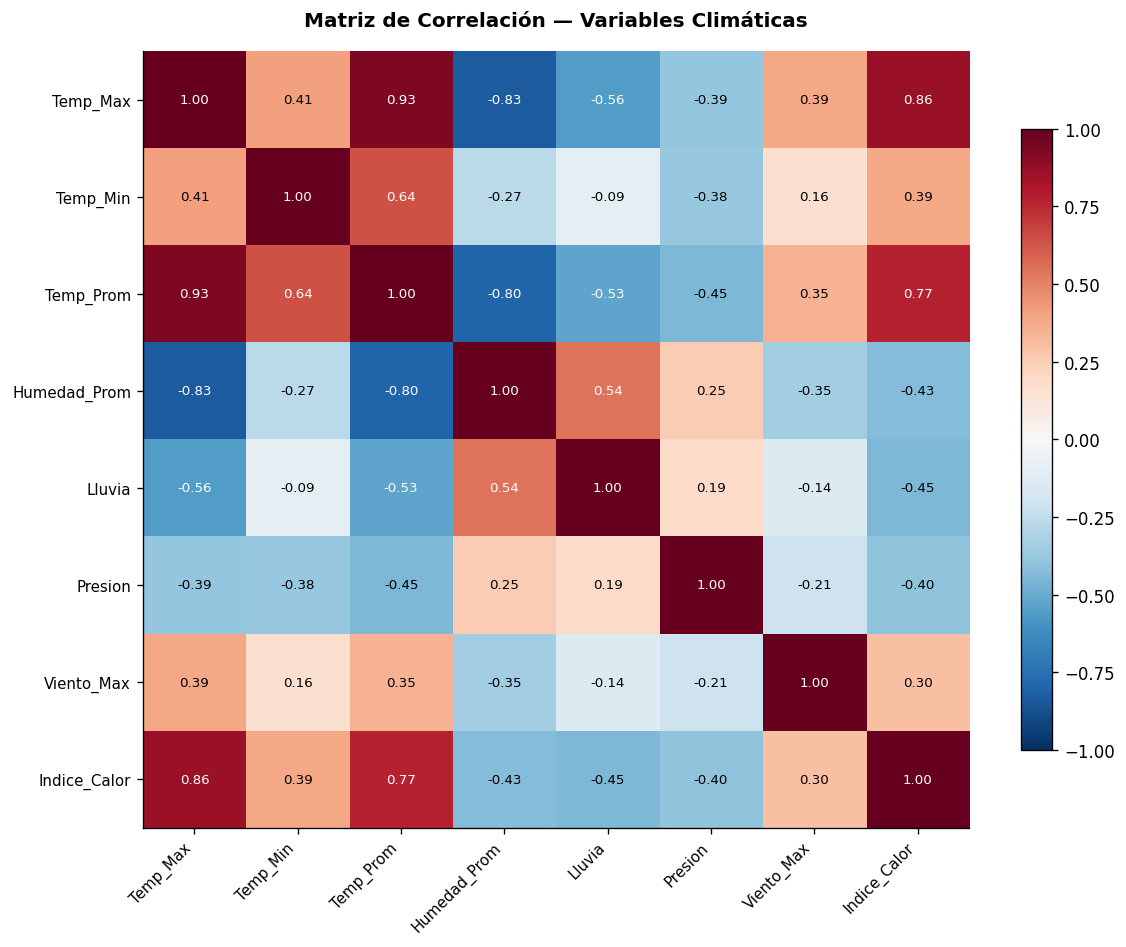

Gráfica guardada en reports/

Correlaciones con Índice de Calor (ordenadas):
Indice_Calor    1.00
Temp_Max        0.86
Temp_Prom       0.77
Temp_Min        0.39
Viento_Max      0.30
Presion        -0.40
Humedad_Prom   -0.43
Lluvia         -0.45


In [25]:
cols_corr = [
    "Temp_Max","Temp_Min","Temp_Prom",
    "Humedad_Prom","Lluvia","Presion",
    "Viento_Max","Indice_Calor"
]

corr = df[cols_corr].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(cols_corr)))
ax.set_yticks(range(len(cols_corr)))
ax.set_xticklabels(cols_corr, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(cols_corr, fontsize=9)

for i in range(len(cols_corr)):
    for j in range(len(cols_corr)):
        val = corr.iloc[i, j]
        color = "white" if abs(val) > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=8, color=color)

ax.set_title("Matriz de Correlación — Variables Climáticas",
             fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "correlaciones.png", dpi=150)
plt.show()
print("Gráfica guardada en reports/")
print()
print("Correlaciones con Índice de Calor (ordenadas):")
print(corr["Indice_Calor"].sort_values(ascending=False).to_string())

## Interpretación de la Matriz de Correlación

La matriz de correlación muestra la relación existente entre las diferentes variables climáticas analizadas para David, Chiriquí.  
Cada celda contiene un valor de correlación que varía entre -1 y 1.

### Escala de correlación

- **1** → correlación positiva perfecta.
- **0** → no existe relación.
- **-1** → correlación negativa perfecta.

Los colores ayudan a interpretar la intensidad de la relación:

- 🔴 **Rojo:** correlación positiva.
- 🔵 **Azul:** correlación negativa.

---

## Relación entre Temperatura Máxima y Temperatura Promedio

La correlación entre `Temp_Max` y `Temp_Prom` es de:

```math
r = 0.93

## 13. Días más extremos

In [26]:
print("=" * 55)
print("  TOP 10 DÍAS MÁS CALUROSOS (Temp Máxima)")
print("=" * 55)
top_calor = df.nlargest(10, "Temp_Max")[
    ["Fecha","Temp_Max","Temp_Prom","Humedad_Prom","Indice_Calor","Nivel_Alerta"]
]
print(top_calor.to_string(index=False))

print()
print("=" * 55)
print("  TOP 10 DÍAS CON MAYOR ÍNDICE DE CALOR")
print("=" * 55)
top_indice = df.nlargest(10, "Indice_Calor")[
    ["Fecha","Temp_Max","Humedad_Prom","Indice_Calor","Nivel_Alerta"]
]
print(top_indice.to_string(index=False))

print()
print("=" * 55)
print("  TOP 10 DÍAS MÁS LLUVIOSOS")
print("=" * 55)
top_lluvia = df.nlargest(10, "Lluvia")[
    ["Fecha","Lluvia","Temp_Max","Temp_Prom"]
]
print(top_lluvia.to_string(index=False))

  TOP 10 DÍAS MÁS CALUROSOS (Temp Máxima)
     Fecha  Temp_Max  Temp_Prom  Humedad_Prom  Indice_Calor    Nivel_Alerta
2024-03-11      38.1      29.85         62.46          57.1 PELIGRO EXTREMO
2026-04-14      37.3      30.07         51.25          47.3 PELIGRO EXTREMO
2019-03-17      37.0      30.03         57.25          49.8 PELIGRO EXTREMO
2019-03-18      37.0      29.79         57.25          49.8 PELIGRO EXTREMO
2020-03-10      37.0      29.03         56.29          49.2 PELIGRO EXTREMO
2020-03-11      37.0      28.50         58.46          50.5 PELIGRO EXTREMO
2024-03-12      37.0      30.07         59.96          51.4 PELIGRO EXTREMO
2026-04-13      36.9      29.78         60.54          51.4 PELIGRO EXTREMO
2019-03-10      36.8      29.78         53.04          46.8 PELIGRO EXTREMO
2019-03-11      36.8      29.98         57.96          49.5 PELIGRO EXTREMO

  TOP 10 DÍAS CON MAYOR ÍNDICE DE CALOR
     Fecha  Temp_Max  Humedad_Prom  Indice_Calor    Nivel_Alerta
2020-04-06      